In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

df = pd.read_csv('iris.csv')

print('Dataset loaded:', df.shape)
df.head()

Dataset loaded: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
print('basic info:')
df.info()
print('columns:', df.columns.tolist())
print('species counts:', df['Species'].value_counts())
df.describe()

basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
species counts: Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 1. One-Sample t-test

testing if setosa sepal length mean = 5.0 cm

H0: mean = 5.0
H1: mean != 5.0
alpha = 0.05

sample size: 50
mean: 5.006
std: 0.352


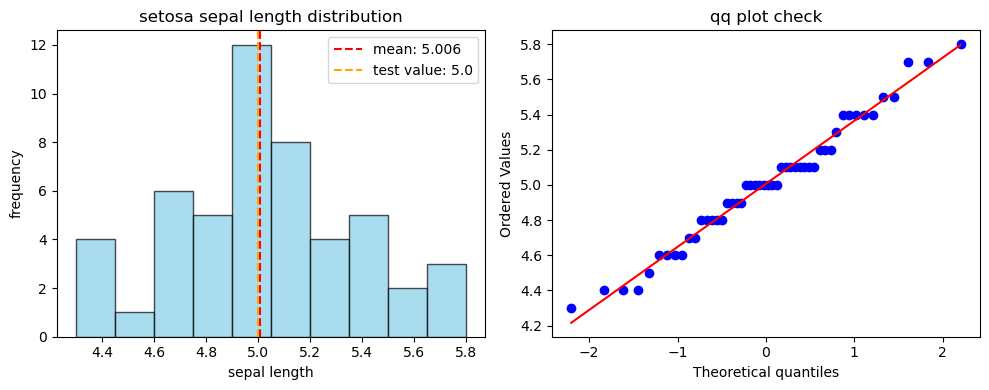

In [3]:
setosa_data = df[df['Species'] == 'Iris-setosa']['SepalLengthCm']

print(f'sample size: {len(setosa_data)}')
print(f'mean: {setosa_data.mean():.3f}')
print(f'std: {setosa_data.std():.3f}')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(setosa_data, bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(setosa_data.mean(), color='red', linestyle='--', label=f'mean: {setosa_data.mean():.3f}')
plt.axvline(5.0, color='orange', linestyle='--', label='test value: 5.0')
plt.xlabel('sepal length')
plt.ylabel('frequency')
plt.title('setosa sepal length distribution')
plt.legend()

plt.subplot(1, 2, 2)
stats.probplot(setosa_data, dist='norm', plot=plt)
plt.title('qq plot check')
plt.tight_layout()
plt.show()

In [4]:
test_val = 5.0
t_stat, p_val = stats.ttest_1samp(setosa_data, test_val)

print('t-test results:')
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'df: {len(setosa_data) - 1}')

alpha = 0.05
if p_val < alpha:
    print(f'p-value ({p_val:.4f}) < alpha ({alpha})')
    print('reject H0')
    print(f'setosa mean sepal length is significantly different from {test_val}')
else:
    print(f'p-value ({p_val:.4f}) >= alpha ({alpha})')
    print('fail to reject H0')
    print(f'no evidence that setosa mean differs from {test_val}')

t-test results:
t-statistic: 0.1204
p-value: 0.9047
df: 49
p-value (0.9047) >= alpha (0.05)
fail to reject H0
no evidence that setosa mean differs from 5.0


## 2. Two-Sample t-test

comparing petal width of versicolor and virginica

H0: mean1 = mean2 
H1: mean1 != mean2

descriptive stats:
versicolor - n: 50, mean: 1.326, sd: 0.198
virginica - n: 50, mean: 2.026, sd: 0.275


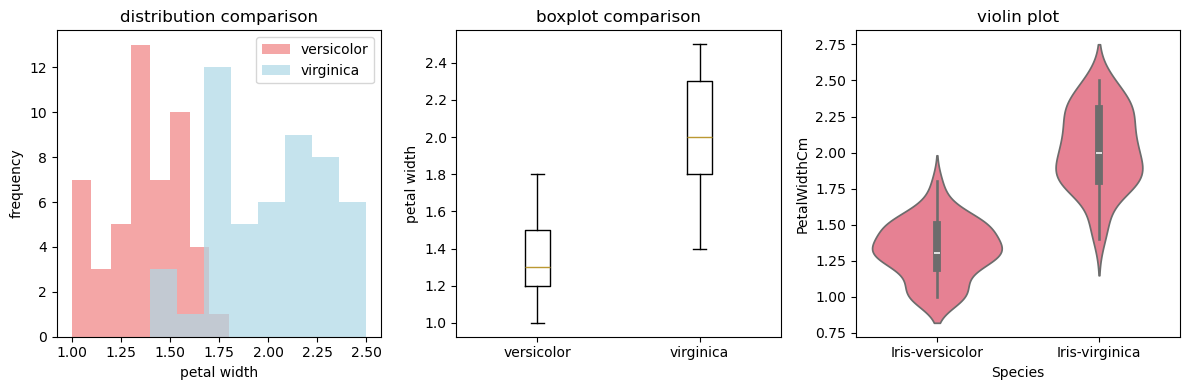

In [5]:
versi_width = df[df['Species'] == 'Iris-versicolor']['PetalWidthCm']
virgi_width = df[df['Species'] == 'Iris-virginica']['PetalWidthCm']

print('descriptive stats:')
print(f'versicolor - n: {len(versi_width)}, mean: {versi_width.mean():.3f}, sd: {versi_width.std():.3f}')
print(f'virginica - n: {len(virgi_width)}, mean: {virgi_width.mean():.3f}, sd: {virgi_width.std():.3f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(versi_width, bins=8, alpha=0.7, label='versicolor', color='lightcoral')
plt.hist(virgi_width, bins=8, alpha=0.7, label='virginica', color='lightblue')
plt.xlabel('petal width')
plt.ylabel('frequency')
plt.title('distribution comparison')
plt.legend()

plt.subplot(1, 3, 2)
plt.boxplot([versi_width, virgi_width], labels=['versicolor', 'virginica'])
plt.ylabel('petal width')
plt.title('boxplot comparison')

plt.subplot(1, 3, 3)
species_data = df[df['Species'].isin(['Iris-versicolor', 'Iris-virginica'])]
sns.violinplot(data=species_data, x='Species', y='PetalWidthCm')
plt.title('violin plot')
plt.tight_layout()
plt.show()

In [6]:
# checking assumptions
_, p_norm1 = stats.shapiro(versi_width)
_, p_norm2 = stats.shapiro(virgi_width)
print(f'normality test - versicolor: {p_norm1:.4f}')
print(f'normality test - virginica: {p_norm2:.4f}')

_, p_var = stats.levene(versi_width, virgi_width)
print(f'equal variance test: {p_var:.4f}')

equal_var = p_var > 0.05
print(f'equal variances: {equal_var}')

# t-test
t_stat, p_val = stats.ttest_ind(versi_width, virgi_width, equal_var=equal_var)
print(f't-statistic: {t_stat:.4f}')
print(f'p-value: {p_val:.4f}')

if equal_var:
    df_val = len(versi_width) + len(virgi_width) - 2
    test_type = "equal var t-test"
else:
    s1, s2 = versi_width.var(), virgi_width.var()
    n1, n2 = len(versi_width), len(virgi_width)
    df_val = (s1/n1 + s2/n2)**2 / ((s1/n1)**2/(n1-1) + (s2/n2)**2/(n2-1))
    test_type = "welch t-test"

print(f'test type: {test_type}')
print(f'df: {df_val:.2f}')

alpha = 0.05
if p_val < alpha:
    print(f'p-value ({p_val:.4f}) < alpha ({alpha})')
    print('reject H0 - significant difference between species')
else:
    print(f'p-value ({p_val:.4f}) >= alpha ({alpha})')
    print('fail to reject H0 - no significant difference')


normality test - versicolor: 0.0273
normality test - virginica: 0.0870
equal variance test: 0.0120
equal variances: False
t-statistic: -14.6254
p-value: 0.0000
test type: welch t-test
df: 89.04
p-value (0.0000) < alpha (0.05)
reject H0 - significant difference between species


## 3. Chi-Square Test

testing if sepal length category independent of species

H0: independent (no association)
H1: dependent (association exists)

median sepal length: 5.80
contingency table:
SepalLength_Cat  Long  Short  All
Species                          
Iris-setosa         1     49   50
Iris-versicolor    29     21   50
Iris-virginica     47      3   50
All                77     73  150
percentages:
SepalLength_Cat  Long  Short
Species                     
Iris-setosa       2.0   98.0
Iris-versicolor  58.0   42.0
Iris-virginica   94.0    6.0


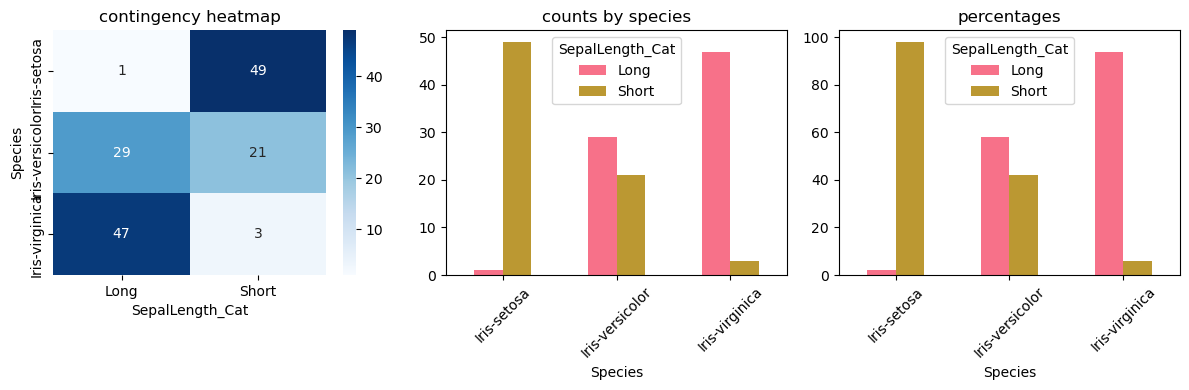

In [7]:
median_sepal = df['SepalLengthCm'].median()
print(f'median sepal length: {median_sepal:.2f}')

df['SepalLength_Cat'] = df['SepalLengthCm'].apply(lambda x: 'Long' if x >= median_sepal else 'Short')

# contingency table
cont_table = pd.crosstab(df['Species'], df['SepalLength_Cat'], margins=True)
print('contingency table:')
print(cont_table)

# percentages
pct_table = pd.crosstab(df['Species'], df['SepalLength_Cat'], normalize='index') * 100
print('percentages:')
print(pct_table.round(2))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
cont_plot = cont_table.iloc[:-1, :-1]
sns.heatmap(cont_plot, annot=True, fmt='d', cmap='Blues')
plt.title('contingency heatmap')

plt.subplot(1, 3, 2)
cont_plot.plot(kind='bar', ax=plt.gca())
plt.title('counts by species')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
pct_table.plot(kind='bar', ax=plt.gca())
plt.title('percentages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
observed = cont_table.iloc[:-1, :-1].values
chi2_stat, p_val, dof, expected = chi2_contingency(observed)

print('chi-square test:')
print(f'chi2 statistic: {chi2_stat:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'df: {dof}')

alpha = 0.05
if p_val < alpha:
    print(f'p-value ({p_val:.4f}) < alpha ({alpha})')
    print('reject H0 - significant association between sepal length and species')
else:
    print(f'p-value ({p_val:.4f}) >= alpha ({alpha})')
    print('fail to reject H0 - sepal length independent of species')

chi-square test:
chi2 statistic: 86.0345
p-value: 0.0000
df: 2
p-value (0.0000) < alpha (0.05)
reject H0 - significant association between sepal length and species


## 4. Correlation Test

testing correlation between sepal length and petal length

H0: correlation = 0
H1: correlation != 0

sepal length - mean: 5.843, sd: 0.828
petal length - mean: 3.759, sd: 1.764


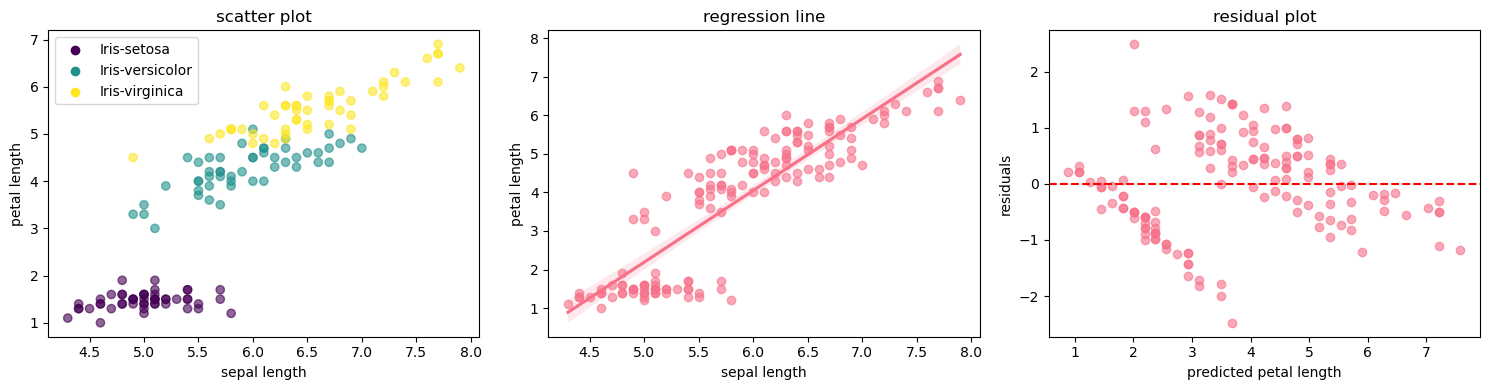

In [9]:
sepal_len = df['SepalLengthCm']
petal_len = df['PetalLengthCm']

print(f'sepal length - mean: {sepal_len.mean():.3f}, sd: {sepal_len.std():.3f}')
print(f'petal length - mean: {petal_len.mean():.3f}, sd: {petal_len.std():.3f}')

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.scatter(sepal_len, petal_len, alpha=0.6, c=df['Species'].astype('category').cat.codes, cmap='viridis')
plt.xlabel('sepal length')
plt.ylabel('petal length')
plt.title('scatter plot')
species_names = df['Species'].unique()
for i, species in enumerate(species_names):
    plt.scatter([], [], c=plt.cm.viridis(i/2), label=species)
plt.legend()

plt.subplot(1, 3, 2)
sns.regplot(x=sepal_len, y=petal_len, scatter_kws={'alpha':0.6})
plt.xlabel('sepal length')
plt.ylabel('petal length')
plt.title('regression line')

plt.subplot(1, 3, 3)
from scipy.stats import linregress
slope, intercept, r_val, p_val_reg, std_err = linregress(sepal_len, petal_len)
predicted = slope * sepal_len + intercept
residuals = petal_len - predicted
plt.scatter(predicted, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('predicted petal length')
plt.ylabel('residuals')
plt.title('residual plot')
plt.tight_layout()
plt.show()

In [10]:
corr_coef, p_val = stats.pearsonr(sepal_len, petal_len)

print('pearson correlation:')
print(f'correlation r: {corr_coef:.4f}')
print(f'p-value: {p_val:.4f}')
print(f'sample size: {len(sepal_len)}')

# r-squared
r_squared = corr_coef ** 2
print(f'r-squared: {r_squared:.4f}')
print(f'variance explained: {r_squared * 100:.2f}%')

alpha = 0.05
if p_val < alpha:
    print(f'p-value ({p_val:.4f}) < alpha ({alpha})')
    print('reject H0 - significant correlation exists')
else:
    print(f'p-value ({p_val:.4f}) >= alpha ({alpha})')
    print('fail to reject H0 - no significant correlation')

abs_r = abs(corr_coef)
if abs_r < 0.3:
    strength = 'weak'
elif abs_r < 0.7:
    strength = 'moderate'
else:
    strength = 'strong'

direction = 'positive' if corr_coef > 0 else 'negative'
print(f'correlation: {strength} {direction}')

pearson correlation:
correlation r: 0.8718
p-value: 0.0000
sample size: 150
r-squared: 0.7600
variance explained: 76.00%
p-value (0.0000) < alpha (0.05)
reject H0 - significant correlation exists
correlation: strong positive
